In [ ]:
pip install mlxtend


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.plotting import plot_decision_regions


In [ ]:
df = pd.DataFrame()

In [ ]:
df['X1'] = [1,2,3,4,5,6,7,8,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['Label'] = [1,1,0,1,0,1,0,1,0,0]

In [ ]:
df

,X1,X2,Label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,7,5,0
7,8,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

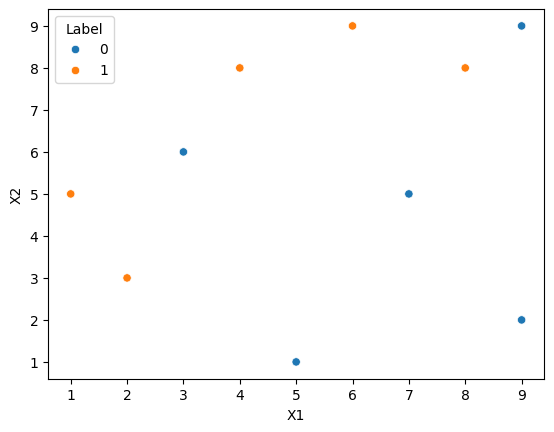

In [ ]:
sns.scatterplot(
    data = df,
    x = 'X1',
    y = 'X2',
    hue = 'Label'
)

In [ ]:
df['weight'] = 1 / df.shape[0]

In [ ]:
df

,X1,X2,Label,weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,7,5,0,0.1
7,8,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt1 = DecisionTreeClassifier(max_depth = 1)

In [ ]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [ ]:
# Step - 2 Train the first model

dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

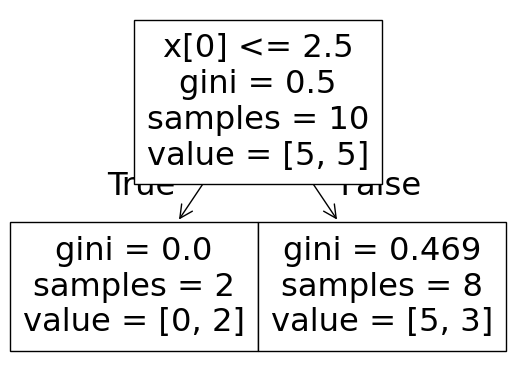

In [ ]:
from sklearn.tree import plot_tree

plot_tree(dt1)

<Axes: >

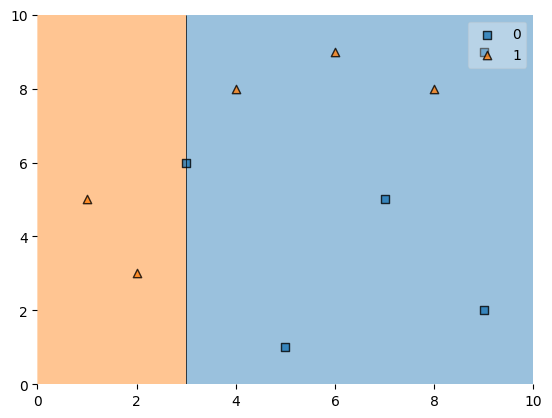

In [ ]:
plot_decision_regions(X,y,dt1)

In [ ]:
df['y_pred'] = dt1.predict(X)

In [ ]:
df

,X1,X2,Label,weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,7,5,0,0.1,0
7,8,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [ ]:
def calculate_model_weight(error):

    return 0.5 * np.log((1 - error) / (error))

In [ ]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [ ]:
def update_row_weight(row,alpha = 0.423):

    if row['Label'] == row['y_pred']:
        return row['weight'] * np.exp(-alpha)
    else:
        return row['weight'] * np.exp(alpha)

In [ ]:
df['update_weight'] = df.apply(update_row_weight,axis = 1)

In [ ]:
df

,X1,X2,Label,weight,y_pred,update_weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,7,5,0,0.1,0,0.065508
7,8,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [ ]:
df['update_weight'].sum()

np.float64(0.9165153319682015)

In [ ]:
df['normalized_weights'] = df['update_weight'] / df['update_weight'].sum()

In [ ]:
df['normalized_weights'].sum()

np.float64(1.0)

In [ ]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [ ]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [ ]:
df

,X1,X2,Label,weight,y_pred,update_weight,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,7,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,8,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [ ]:
def create_new_dataset(df):

    indics = []

    for i in range(df.shape[0]):
        a = np.random.random()

        for index, row in df.iterrows():
            if row['cumsum_lower'] < a and a< row['cumsum_upper']:
                indics.append(index)
                break

    return indics

In [ ]:
index_value = create_new_dataset(df)

index_value

[7, 4, 4, 3, 8, 7, 5, 7, 6, 5]

In [ ]:
second_df = df.iloc[index_value,[0,1,2,3]]

second_df

,X1,X2,Label,weight
7,8,8,1,0.1
4,5,1,0,0.1
4,5,1,0,0.1
3,4,8,1,0.1
8,9,9,0,0.1
7,8,8,1,0.1
5,6,9,1,0.1
7,8,8,1,0.1
6,7,5,0,0.1
5,6,9,1,0.1


In [ ]:
dt2 = DecisionTreeClassifier(max_depth = 1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [ ]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 6.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.625, 0.5, '  False')]

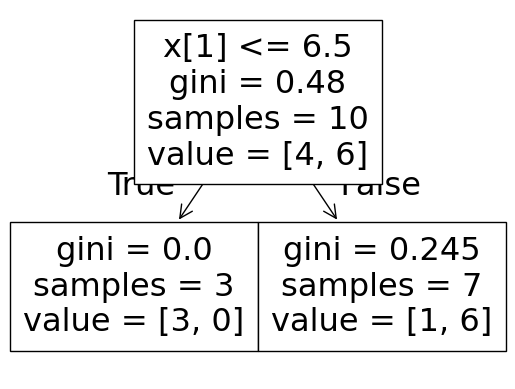

In [ ]:
plot_tree(dt2)

<Axes: >

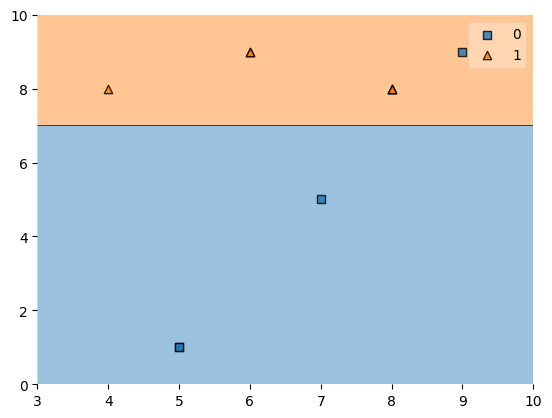

In [ ]:
plot_decision_regions(X,y,dt2)

In [ ]:
second_df['y_pred'] = dt2.predict(X)

In [ ]:
second_df

,X1,X2,Label,weight,y_pred
7,8,8,1,0.1,1
4,5,1,0,0.1,0
4,5,1,0,0.1,0
3,4,8,1,0.1,1
8,9,9,0,0.1,1
7,8,8,1,0.1,1
5,6,9,1,0.1,1
7,8,8,1,0.1,1
6,7,5,0,0.1,0
5,6,9,1,0.1,1


In [ ]:
alpha2 = calculate_model_weight(0.1)

In [ ]:
alpha2

np.float64(1.0986122886681098)

In [ ]:
# Step 4 : update weights

def update_row_weight(row,alpha = 1.09):

    if row['Label'] == row['y_pred']:
        return row['weight'] * np.exp(-alpha)
    else:
        return row['weight'] * np.exp(alpha)

In [ ]:
second_df['update_weight'] = second_df.apply(update_row_weight,axis = 1)

In [ ]:
second_df

,X1,X2,Label,weight,y_pred,update_weight
7,8,8,1,0.1,1,0.033622
4,5,1,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
3,4,8,1,0.1,1,0.033622
8,9,9,0,0.1,1,0.297427
7,8,8,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622
7,8,8,1,0.1,1,0.033622
6,7,5,0,0.1,0,0.033622
5,6,9,1,0.1,1,0.033622


In [ ]:
second_df['normalized'] = second_df['update_weight'] / second_df['update_weight'].sum()

In [ ]:
second_df

,X1,X2,Label,weight,y_pred,update_weight,normalized
7,8,8,1,0.1,1,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,1,0.297427,0.495694
7,8,8,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
7,8,8,1,0.1,1,0.033622,0.056034
6,7,5,0,0.1,0,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034


In [ ]:
second_df['normalized'].sum()

np.float64(0.9999999999999999)

In [ ]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized'])

In [ ]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized']

In [ ]:
second_df

,X1,X2,Label,weight,y_pred,update_weight,normalized,cumsum_upper,cumsum_lower
7,8,8,1,0.1,1,0.033622,0.056034,0.056034,0.000000
4,5,1,0,0.1,0,0.033622,0.056034,0.112068,0.056034
4,5,1,0,0.1,0,0.033622,0.056034,0.168102,0.112068
3,4,8,1,0.1,1,0.033622,0.056034,0.224136,0.168102
8,9,9,0,0.1,1,0.297427,0.495694,0.719830,0.224136
7,8,8,1,0.1,1,0.033622,0.056034,0.775864,0.719830
5,6,9,1,0.1,1,0.033622,0.056034,0.831898,0.775864
7,8,8,1,0.1,1,0.033622,0.056034,0.887932,0.831898
6,7,5,0,0.1,0,0.033622,0.056034,0.943966,0.887932
5,6,9,1,0.1,1,0.033622,0.056034,1.000000,0.943966


In [ ]:
index_value = create_new_dataset(second_df)

In [ ]:
thrid_df = second_df.iloc[index_value,[0,1,2,3]]

In [ ]:
thrid_df

,X1,X2,Label,weight
6,7,5,0,0.1
6,7,5,0,0.1
6,7,5,0,0.1
6,7,5,0,0.1
7,8,8,1,0.1
6,7,5,0,0.1
7,8,8,1,0.1
7,8,8,1,0.1
8,9,9,0,0.1
7,8,8,1,0.1


In [ ]:
dt3 = DecisionTreeClassifier(max_depth = 1)

X = thrid_df.iloc[:,0:2].values
y = thrid_df.iloc[:,2].values

In [ ]:
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 6.5\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

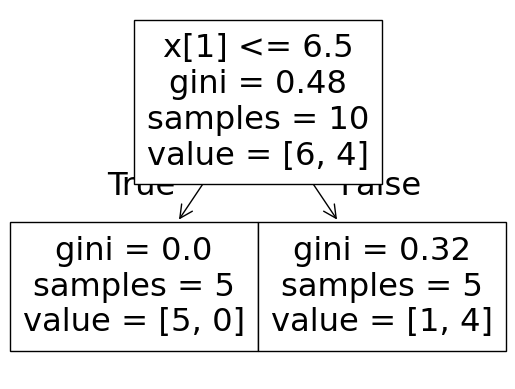

In [ ]:
plot_tree(dt3)

<Axes: >

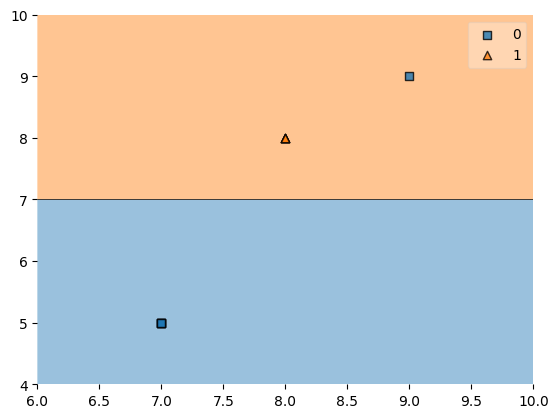

In [ ]:
plot_decision_regions(X,y,dt3)

In [ ]:
thrid_df['y_pred'] = dt3.predict(X)

In [ ]:
thrid_df

,X1,X2,Label,weight,y_pred
6,7,5,0,0.1,0
6,7,5,0,0.1,0
6,7,5,0,0.1,0
6,7,5,0,0.1,0
7,8,8,1,0.1,1
6,7,5,0,0.1,0
7,8,8,1,0.1,1
7,8,8,1,0.1,1
8,9,9,0,0.1,1
7,8,8,1,0.1,1


In [ ]:
alpha3 = calculate_model_weight(0.1)
alpha3

np.float64(1.0986122886681098)

In [ ]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 1.0986122886681098


## Prediction

In [ ]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [ ]:
dt2.predict(query)

array([0])

In [ ]:
dt3.predict(query)

array([0])

In [ ]:
alpha1 * 1 + alpha2 * -1 + alpha3 * -1

np.float64(-1.7735756471426178)

In [ ]:
np.sign(-1.7735756471426178)

np.float64(-1.0)

In [ ]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [ ]:
dt2.predict(query)

array([1])

In [ ]:
dt3.predict(query)

array([1])

In [ ]:
alpha1 * 1 + alpha2 * -1 + alpha3 * -1

np.float64(-1.7735756471426178)

In [ ]:
np.sign(-1.7735756471426178)

np.float64(-1.0)